# Rep. 3. Checkpoint 3. Limitaciones de Black-Scholes y modelos alternativos
## Eduardo Veytia Hernández

Esta actividad es requisito para el reporte integrador 3.

Usando el código visto en clase, simularás y compararás los modelos de Heston y Merton contra el GBM estándar para entender cómo cada uno modifica la distribución del precio final y qué implicaciones tiene eso para el pricing de opciones.

# Contexto
Black-Scholes asume que el subyacente sigue un GBM con volatilidad constante. Heston y Merton relajan ese supuesto de formas distintas: Heston hace que la volatilidad fluctúe en el tiempo, Merton agrega saltos abruptos al proceso de precios. Ambos producen distribuciones con colas más gruesas — especialmente hacia la izquierda — que BS ignora sistemáticamente.

# Instrucciones
Usando el código de clase como base, reproduce las dos simulaciones con los parámetros vistos en clase y genera las gráficas de comparación para cada modelo.

Después, modifica los siguientes parámetros uno a la vez y observa cómo cambian las distribuciones:

Para Heston: prueba con ξ = 0.1, ξ = 0.4 y ξ = 0.9

Para Merton: prueba con λ = 1, λ = 4 y λ = 15

Cada variación debe producir su propia gráfica comparativa. Incluye todas las gráficas en tu entregable con un título claro que indique el parámetro y el valor usado.



Curtosis excess :15.14   (normal = 0)
Asimetría       :-0.32    (normal = 0)


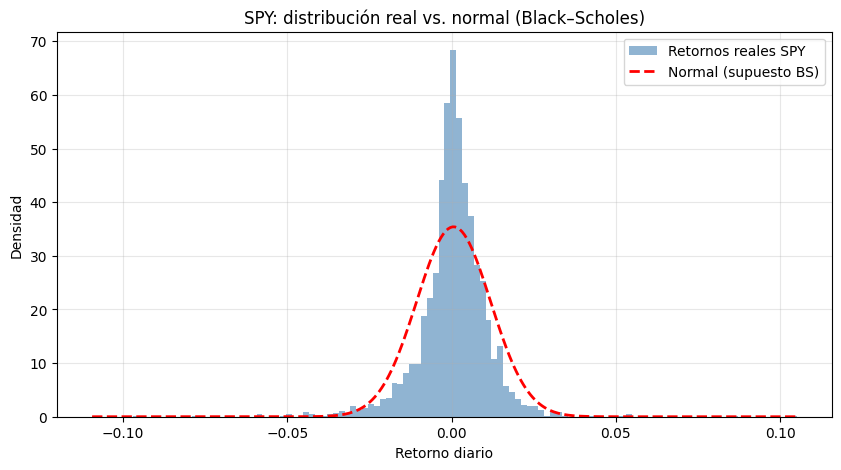

In [2]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

data     = yf.Ticker('SPY').history(period='10y')['Close']
retornos = data.pct_change().dropna()

print(f"Curtosis excess :{kurtosis(retornos):.2f}   (normal = 0)")
print(f"Asimetría       :{skew(retornos):.2f}    (normal = 0)")

x = np.linspace(retornos.min(), retornos.max(), 300)
plt.figure(figsize=(10, 5))
plt.hist(retornos, bins=120, density=True, alpha=0.6,
         color='steelblue', label='Retornos reales SPY')
plt.plot(x, norm.pdf(x, retornos.mean(), retornos.std()),
         'r--', linewidth=2, label='Normal (supuesto BS)')
plt.xlabel('Retorno diario')
plt.ylabel('Densidad')
plt.title('SPY: distribución real vs. normal (Black–Scholes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    """
    S0    : precio inicial
    v0    : varianza inicial
    mu    : drift
    kappa : velocidad de reversión
    theta : varianza de largo plazo
    xi    : vol of vol
    rho   : correlación precio-volatilidad
    T     : tiempo en años
    N     : número de pasos
    M     : número de simulaciones
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # correlación

        v_pos = np.maximum(v[:, t-1], 0)           # evita varianza negativa

        v[:, t] = (v_pos
                   + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)

        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * Zs
        )
    return S, v

# Parámetros
S0    = 669.03
v0    = 0.04
mu    = 0.042
kappa = 2.0
theta = 0.04
xi    = 0.3
rho   = -0.7
T     = 1.0
N     = 252
M     = 1000

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

# --- Comparación: GBM estándar vs. Heston ---
sigma_const = 0.20
dt = T / N
Z  = np.random.randn(M, N)
S_gbm = np.zeros((M, N + 1))
S_gbm[:, 0] = S0
for t in range(1, N + 1):
    S_gbm[:, t] = S_gbm[:, t-1] * np.exp(
        (mu - 0.5 * sigma_const**2) * dt + sigma_const * np.sqrt(dt) * Z[:, t-1]
    )

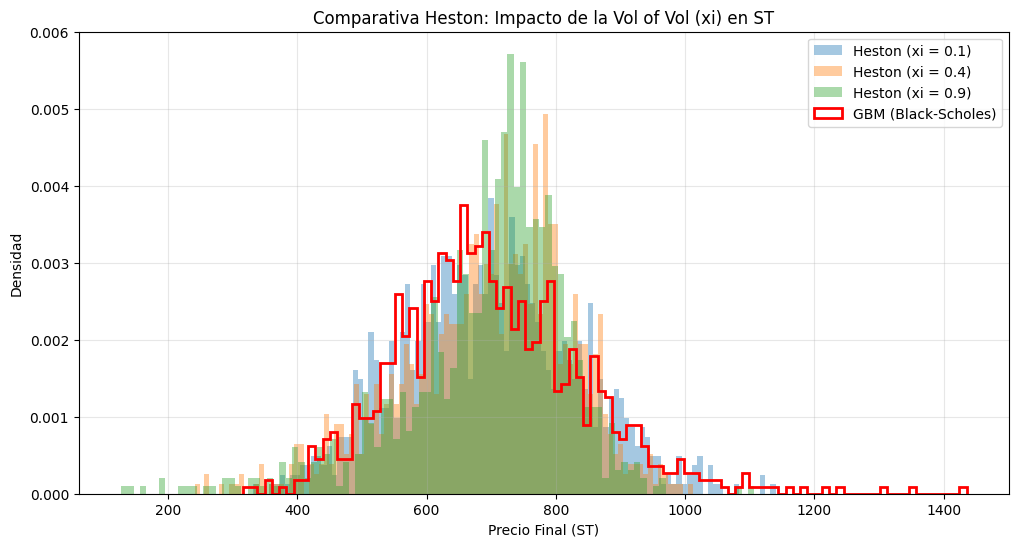

In [5]:
# --- Variaciones de Heston (xi) ---
valores_xi = [0.1, 0.4, 0.9]
plt.figure(figsize=(12, 6))

for xi_val in valores_xi:
    # Simulamos con el xi correspondiente
    S_h, _ = simular_heston(S0, v0, mu, kappa, theta, xi_val, rho, T, N, M)
    
    # Graficamos la distribución del precio final
    plt.hist(S_h[:, -1], bins=100, density=True, alpha=0.4, 
             label=f'Heston (xi = {xi_val})')

# Referencia de Black-Scholes (GBM)
plt.hist(S_gbm[:, -1], bins=100, density=True, histtype='step', 
         color='red', linewidth=2, label='GBM (Black-Scholes)')

plt.title('Comparativa Heston: Impacto de la Vol of Vol (xi) en ST', fontsize=12)
plt.xlabel('Precio Final (ST)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):
    """
    lam     : intensidad de saltos (saltos/año)
    mu_j    : media del log-salto
    sigma_j : desviación del log-salto
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        # Componente difusiva (GBM)
        Z     = np.random.randn(M)
        gbm   = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

        # Componente de saltos (Poisson)
        n_saltos  = np.random.poisson(lam * dt, M)          # número de saltos en dt
        log_salto = np.array([
            np.sum(np.random.normal(mu_j, sigma_j, n))
            if n > 0 else 0.0
            for n in n_saltos
        ])

        S[:, t] = S[:, t-1] * np.exp(gbm + log_salto)

    return S

# Parámetros
S0      = 669.03
mu      = 0.042
sigma   = 0.15
lam     = 4        # ~4 saltos por año
mu_j    = -0.05    # saltos promedio de -5%
sigma_j = 0.10
T       = 1.0
N       = 252
M       = 1000

S_merton = simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M)

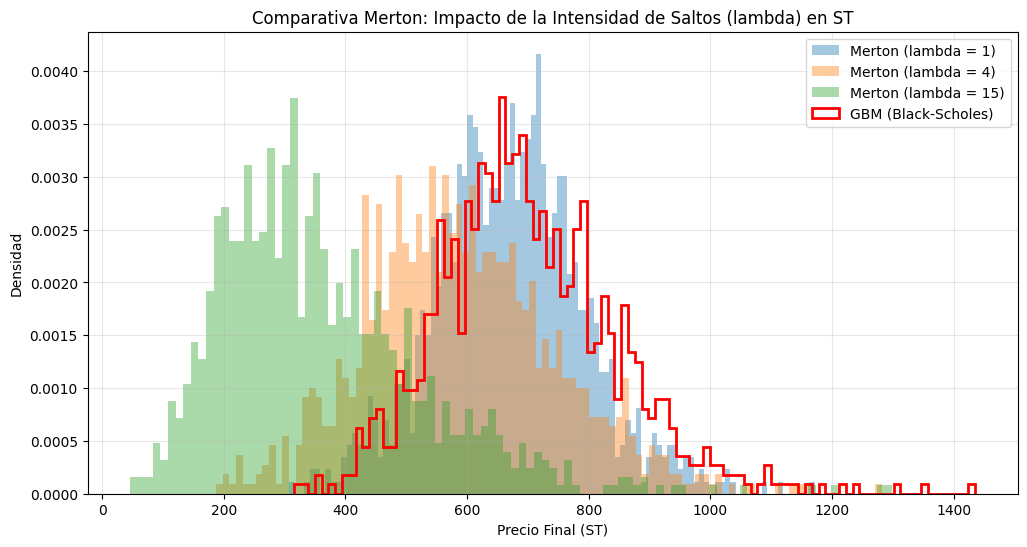

In [6]:
# --- Variaciones de Merton (lambda) ---
valores_lam = [1, 4, 15]
plt.figure(figsize=(12, 6))

for lam_val in valores_lam:
    # Simulamos con el lambda correspondiente
    S_m = simular_merton(S0, mu, sigma, lam_val, mu_j, sigma_j, T, N, M)
    
    # Graficamos la distribución del precio final
    plt.hist(S_m[:, -1], bins=100, density=True, alpha=0.4, 
             label=f'Merton (lambda = {lam_val})')

# Referencia de Black-Scholes (GBM)
plt.hist(S_gbm[:, -1], bins=100, density=True, histtype='step', 
         color='red', linewidth=2, label='GBM (Black-Scholes)')

plt.title('Comparativa Merton: Impacto de la Intensidad de Saltos (lambda) en ST', fontsize=12)
plt.xlabel('Precio Final (ST)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

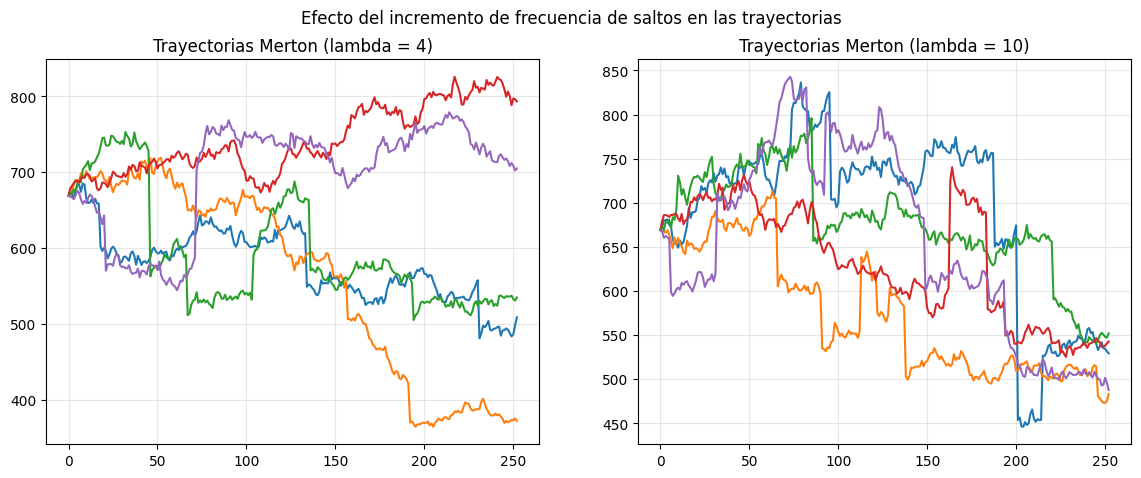

In [7]:
# --- TAREA: Observación específica de trayectorias Merton ---
S_m_4 = simular_merton(S0, mu, sigma, 4, mu_j, sigma_j, T, N, M)
S_m_10 = simular_merton(S0, mu, sigma, 10, mu_j, sigma_j, T, N, M)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Graficamos las primeras 5 trayectorias para cada caso
ax[0].plot(S_m_4[:5].T)
ax[0].set_title('Trayectorias Merton (lambda = 4)')
ax[0].grid(True, alpha=0.3)

ax[1].plot(S_m_10[:5].T)
ax[1].set_title('Trayectorias Merton (lambda = 10)')
ax[1].grid(True, alpha=0.3)

plt.suptitle('Efecto del incremento de frecuencia de saltos en las trayectorias')
plt.show()

# Preguntas
Responde dentro del notebook como celdas de texto (Markdown), tal vez necesites investigar para contestar:

- **En la simulación de Heston, ¿qué efecto tiene aumentar ξ (vol of vol) sobre la distribución del precio final? ¿Y sobre el skew?**

Distribución: Al aumentar la "vol of vol", la distribución se vuelve más leptocúrtica (pico más alto en el centro y colas mucho más anchas). Esto significa que los eventos extremos se vuelven más probables.

Skew: Dado que la correlación ($\rho$) suele ser negativa, un mayor $\xi$ acentúa el sesgo negativo (left skew). Las caídas de precio se vuelven más violentas cuando la volatilidad se dispara.

- **En la simulación de Merton, cambia λ de 4 a 10. ¿Cómo cambian las trayectorias? ¿Y la distribución final?**

Trayectorias: Las líneas de precio dejan de ser suaves y muestran discontinuidades (saltos) mucho más frecuentes. Con $\lambda=10$, el componente de "ruido" por saltos domina sobre el movimiento normal.

Distribución: La distribución final se ensancha masivamente hacia la izquierda (suponiendo $\mu_j$ negativo). La masa de probabilidad se desplaza a precios bajos porque hay más oportunidades de que ocurra un "crash" durante el año.

- **Si el mercado tiene fat tails y BS los ignora, ¿en qué dirección estará sesgado el precio BS de un put muy OTM, sobreestimado o subestimado? ¿Por qué?**

Estará subestimado. Black-Scholes asume una distribución normal donde los eventos extremos (colas) son casi imposibles. Si el mercado real tiene fat tails (como viste en tus gráficas), la probabilidad real de que el precio caiga hasta el strike del Put es mayor a la que calcula BS. Por lo tanto, el precio "justo" es más alto que el de la fórmula.

- **Merton asume que los saltos son predecibles en frecuencia (λ constante). ¿Qué limitación tiene eso en la práctica?**

Los saltos en el mercado no ocurren de manera uniforme. En la realidad, los saltos suelen venir en clústeres de volatilidad (un salto suele provocar otros seguidos durante una crisis). Asumir una frecuencia constante ignora que la probabilidad de saltos aumenta drásticamente en periodos de pánico financiero.

- **¿Por qué crees que BS sigue siendo el estándar de cotización a pesar de que Heston y Merton son más precisos?**

Simplicidad y Calibración: Solo requiere un parámetro no observable (volatilidad). Modelos como Heston requieren calibrar 5 parámetros, lo que aumenta el riesgo de error de modelo.

Lenguaje de Mercado: Funciona como una "regla de cálculo" universal. Los traders no comparan precios, comparan volatilidades implícitas, y BS es la herramienta estándar para traducir de una a otra de forma rápida y eficiente.
